# **ORANGE SUMMER CHALLENGE - AI Busness for Accelerator**

## **TACHE N-1 : NETTOYAGE DE DONNEE**

### **1) Importation des bibliothèques**

In [3]:
import numpy as np
import pandas as pd

In [4]:
# Vérification des versions 
np.__version__

'1.26.4'

In [5]:
# Verification de la version de pandas
pd.__version__

'2.2.2'

### **2) Lecture du dataset**

In [6]:
dataset = pd.read_csv("clients.csv")

### **3) Exploration du dataset**

In [7]:
# Affichage des information globale du dataset
dataset.shape

(915, 12)

In [8]:
# Affichage des 5 premieres lignes pour une vuue globale
dataset.head()

,client_id,anciennete_mois,age,region,type_offre,moyen_paiement,conso_data_go,conso_voix_min,conso_sms,nb_contacts_support,nb_incidents_reseau,churn
0,64,60,42.0,Île-de-France,Multi-play,Carte bancaire,23.1,0.0,19.0,0,0,0
1,678,43,60.0,Bretagne,Internet Seul,Prélèvement,NaN,189.0,13.0,1,0,0
2,141,33,68.0,Nouvelle-Aquitaine,Multi-play,Carte bancaire,6.1,158.0,6.0,0,0,0
3,54,3,50.0,Auvergne-Rhône-Alpes,Multi-play,Prélèvement,13.7,191.0,9.0,0,0,0
4,826,4,51.0,Grand Est,Mobile Seul,Prélèvement,14.9,215.0,28.0,1,0,1


In [9]:
# A ffichage d'informations générales
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            915 non-null    int64  
 1   anciennete_mois      915 non-null    int64  
 2   age                  868 non-null    float64
 3   region               895 non-null    object 
 4   type_offre           915 non-null    object 
 5   moyen_paiement       915 non-null    object 
 6   conso_data_go        834 non-null    float64
 7   conso_voix_min       915 non-null    float64
 8   conso_sms            915 non-null    float64
 9   nb_contacts_support  915 non-null    int64  
 10  nb_incidents_reseau  915 non-null    int64  
 11  churn                915 non-null    int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 85.9+ KB


### **4) Identification des valeurs manquantes**

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            915 non-null    int64  
 1   anciennete_mois      915 non-null    int64  
 2   age                  868 non-null    float64
 3   region               895 non-null    object 
 4   type_offre           915 non-null    object 
 5   moyen_paiement       915 non-null    object 
 6   conso_data_go        834 non-null    float64
 7   conso_voix_min       915 non-null    float64
 8   conso_sms            915 non-null    float64
 9   nb_contacts_support  915 non-null    int64  
 10  nb_incidents_reseau  915 non-null    int64  
 11  churn                915 non-null    int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 85.9+ KB


In [ ]:
# RESULTAT DES VALEURS MANQUANTES

#A partir de résultat; on constate que ce sont les colonnes age, region et conso_data_go qui ont des valeurs ,anquantes
# Et respective,ent on compte pour chaque colonne :

# colonne "age" : 47 Valeurs manquantes (915 -868 )
# colonne "region" : 20 Valeurs ,anquantes ( 915 - 895)
# colonne "conso_data_go" : 81 Valeurs manquantes ( 915 - 834)

### **5) Identification des doublons**

In [11]:
print("Doublons exacts :", dataset.duplicated().sum())

Doublons exacts : 14


In [12]:
# On constate ainsi au'il ya exactement 14 duplications dans notre dataset

In [13]:
print("Doublons sur client_id :", dataset['client_id'].duplicated().sum())

Doublons sur client_id : 15


In [14]:
# 
#Sachqnt que l'identifiant des clients se doit d'etre unique, nous revenons sur cette colonne de facon spécifique pour determiner et nous rassurer que notre étude se passera dans des meilleures conditions et sur des bonnes bases
# Et il en ressort qu'il ya exacte,et 15 doublons

### **6) Identification des valeurs aberrantes**

In [ ]:
# Ici on va se baser sur toutes les variables quantitatives ( les colonnes ayant les chiffres numériques )

In [15]:
# Définition de la fonction pour détecter les valeurs aberrantes en se basant sur la ,éthode de IQR

In [16]:
def detect_outliers_iqr(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf, borne_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return df[(df[col] < borne_inf) | (df[col] > borne_sup)]

for col in ['age', 'anciennete_mois', 'conso_data_go', 'conso_voix_min', 'conso_sms']:
    n = len(detect_outliers_iqr(dataset, col))
    print(f"{col} : {n} valeurs aberrantes")

age : 2 valeurs aberrantes
anciennete_mois : 0 valeurs aberrantes
conso_data_go : 17 valeurs aberrantes
conso_voix_min : 11 valeurs aberrantes
conso_sms : 38 valeurs aberrantes


In [ ]:
# Suite a la reponse de cette fonction, on peut donc dire que les colonnes :
# 
#la colonne "age" a exactement 02 (deux aberrantes)
# la colonne "anciennete_mois" présente 0 valeur aberrante
# la colonne "conso_data_go" présente 17 valeurs aberrantes
# la colonne "conso_voix_min" présente 11 valeurs aberrantes
# la colonne "conso_sms" présente 38 valeurs aberrantes

### **7) Incohérence des saisies**

In [18]:
# L'incohérence de saisie se fera uniquement sur les variables explicatives, qui sont les variables quantitatives
# Ainsi, nous allons cibles les colonnes mentionnées

In [ ]:
# Nous commencons par la définition de la fonction qui trie les colonnes ayant des variables explicatives

In [17]:
for col in ['region', 'type_offre', 'moyen_paiement']:
    print(f"\n{col} :", dataset[col].unique())


region : ['Île-de-France' 'Bretagne' 'Nouvelle-Aquitaine' 'Auvergne-Rhône-Alpes'
 'Grand Est' 'PACA' 'Occitanie' 'Hauts-de-France' nan]

type_offre : ['Multi-play' 'Internet Seul' 'Mobile Seul' 'MOBILE SEUL' 'INTERNET SEUL'
 'MULTI-PLAY']

moyen_paiement : ['Carte bancaire' 'Prélèvement' 'Virement']


In [19]:
# A l'issu de cette identification, on remarque que, 

# la colonne "region" n'a pas d'incohérence a part le nan" qui represente une valeur manquante
# la colonne "type_offre" a d'incohérence sur les majuscules et les miniscules, il ya des valeurs qui sont entrées en miniscules et d'autres sont entrées en majuscules
# la colonne "moyen_paiement" n'a d'incohérence car on a juste les 3 valeurs uniques 

### **8) Traitement du dataset**

#### **8-1) Traitement des doublons**

In [ ]:
# Sachant qu'il ya juste 15 doublons; ils sont négligeables devant 915 enregistrements

In [22]:
dataset = dataset.drop_duplicates(subset='client_id', keep='first')

In [23]:
dataset.shape

(900, 12)

In [24]:
# Actuellement, on dispose de 900 enregistrements

#### **8-2) Traitement d'incohérences au niveau des variables catégorielles**

In [25]:
for col in ['region', 'type_offre', 'moyen_paiement']:
    dataset[col] = dataset[col].str.strip().str.title()

In [ ]:
# Ici nous changerons simplenent la facon d'entrer les enregisment pour que ca soit synchrone

In [26]:
for col in ['region', 'type_offre', 'moyen_paiement']:
    print(f"\n{col} :", dataset[col].unique())


region : ['Île-De-France' 'Bretagne' 'Nouvelle-Aquitaine' 'Auvergne-Rhône-Alpes'
 'Grand Est' 'Paca' 'Occitanie' 'Hauts-De-France' nan]

type_offre : ['Multi-Play' 'Internet Seul' 'Mobile Seul']

moyen_paiement : ['Carte Bancaire' 'Prélèvement' 'Virement']


In [ ]:
# Ainsi, le resultat devient différent

#### **8-3) Traitement des valeurs manquantes**

In [27]:
dataset['age'] = dataset['age'].fillna(dataset['age'].median())
dataset['region'] = dataset['region'].fillna(dataset['region'].mode()[0])
dataset['conso_data_go'] = dataset.groupby('type_offre')['conso_data_go']\
    .transform(lambda x: x.fillna(x.median()))

In [28]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 900 entries, 0 to 914
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            900 non-null    int64  
 1   anciennete_mois      900 non-null    int64  
 2   age                  900 non-null    float64
 3   region               900 non-null    object 
 4   type_offre           900 non-null    object 
 5   moyen_paiement       900 non-null    object 
 6   conso_data_go        900 non-null    float64
 7   conso_voix_min       900 non-null    float64
 8   conso_sms            900 non-null    float64
 9   nb_contacts_support  900 non-null    int64  
 10  nb_incidents_reseau  900 non-null    int64  
 11  churn                900 non-null    int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 91.4+ KB


In [ ]:
# A ce niveau, nous n'avons plus de valeurs non null; et l'ense,ble de tout fait 900 lignes que representes nos 900 enregistrements

#### **8-4) Traitement des valeurs abberantes**

In [29]:
for col in ['age', 'conso_data_go', 'conso_voix_min']:
    Q1, Q3 = dataset[col].quantile(0.25), dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    dataset[col] = dataset[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

In [30]:
# Nous passons par imputation pour ne pas perdre de données et garder le maximum de ligne ppour une etude un peu plus réussi au final

### **9) Présentation du résultat du nettoyage**

In [31]:
print("Avant :", dataset.shape)
print("\nValeurs manquantes restantes :\n", dataset.isnull().sum())
dataset.info()

Avant : (900, 12)

Valeurs manquantes restantes :
 client_id              0
anciennete_mois        0
age                    0
region                 0
type_offre             0
moyen_paiement         0
conso_data_go          0
conso_voix_min         0
conso_sms              0
nb_contacts_support    0
nb_incidents_reseau    0
churn                  0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 900 entries, 0 to 914
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            900 non-null    int64  
 1   anciennete_mois      900 non-null    int64  
 2   age                  900 non-null    float64
 3   region               900 non-null    object 
 4   type_offre           900 non-null    object 
 5   moyen_paiement       900 non-null    object 
 6   conso_data_go        900 non-null    float64
 7   conso_voix_min       900 non-null    float64
 8   conso_sms            900 non-nu

In [32]:
# Nous constatons que le nettoyage a ete effectuer avec succès et au final on a notre dataset qui est bien propre et pret pour la construction du modèle et des nouvelles analyses

In [33]:
# Enregistrement du dataset final

In [34]:
dataset.to_csv('dataset_propre.csv', index=False)

In [35]:
# Présentation du dataset final

In [36]:
import os
print(os.path.exists('dataset_propre.csv'))

True


In [37]:
dataset_propre = pd.read_csv('dataset_propre.csv')
dataset_propre.head()

,client_id,anciennete_mois,age,region,type_offre,moyen_paiement,conso_data_go,conso_voix_min,conso_sms,nb_contacts_support,nb_incidents_reseau,churn
0,64,60,42.0,Île-De-France,Multi-Play,Carte Bancaire,20.45,0.0,19.0,0,0,0
1,678,43,60.0,Bretagne,Internet Seul,Prélèvement,6.20,189.0,13.0,1,0,0
2,141,33,68.0,Nouvelle-Aquitaine,Multi-Play,Carte Bancaire,6.10,158.0,6.0,0,0,0
3,54,3,50.0,Auvergne-Rhône-Alpes,Multi-Play,Prélèvement,13.70,191.0,9.0,0,0,0
4,826,4,51.0,Grand Est,Mobile Seul,Prélèvement,14.90,215.0,28.0,1,0,1


## **TACHE 2 - ANALYSE EXPLORATOIRE**

### **1) Importation des bibliothèques**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **2) Description générale**

In [39]:
dataset_propre.describe(include='all')

,client_id,anciennete_mois,age,region,type_offre,moyen_paiement,conso_data_go,conso_voix_min,conso_sms,nb_contacts_support,nb_incidents_reseau,churn
count,900.000000,900.000000,900.000000,900,900,900,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
unique,NaN,NaN,NaN,8,3,3,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Nouvelle-Aquitaine,Mobile Seul,Prélèvement,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,135,417,528,NaN,NaN,NaN,NaN,NaN,NaN
mean,450.500000,60.120000,48.112500,NaN,NaN,NaN,7.869056,180.868889,19.974444,1.247778,0.482222,0.131111
std,259.951919,35.295811,17.753633,NaN,NaN,NaN,5.054984,86.435032,19.783658,1.184694,0.693779,0.337710
min,1.000000,1.000000,2.000000,NaN,NaN,NaN,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,225.750000,29.750000,34.000000,NaN,NaN,NaN,4.200000,122.000000,6.000000,0.000000,0.000000,0.000000
50%,450.500000,60.000000,48.000000,NaN,NaN,NaN,6.800000,180.000000,14.000000,1.000000,0.000000,0.000000
75%,675.250000,92.000000,63.250000,NaN,NaN,NaN,10.700000,235.500000,28.000000,2.000000,1.000000,0.000000


In [ ]:
# A ce niveau on a une description générale de notre dataset en ayant de ,anieres globales toutes les caracteristiques de troutes les variables regroupées, dans un seul et meme tableau

### **3) Repartition des churn - le comptage**

In [40]:
print(dataset_propre['churn'].value_counts(normalize=True) * 100)

churn
0    86.888889
1    13.111111
Name: proportion, dtype: float64


In [41]:
# On constate qu'au final en terme de pourcentage on a respectivement

# 13/100 en moyen qui represente la valeur 1
# 87/100 environ represente la valeur 0, d'ou sa domination a vue d'oeil au niveau de head de notre dataset

### **4) Visualisation du résultat du comptage churn**

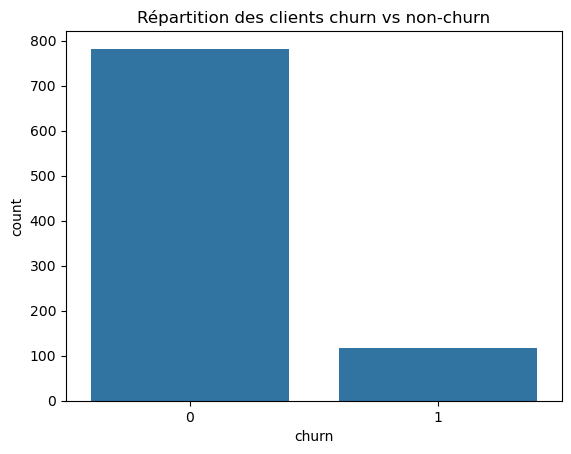

In [42]:
sns.countplot(data=dataset_propre, x='churn')
plt.title("Répartition des clients churn vs non-churn")
plt.show()

In [ ]:
# Cette visualisation nous dponne un apercu générique et sans problème de la repartition

### **5) Présentation des facteurs directe,ent liés au churn**

In [ ]:
# a) Nombre d'incidents réseau

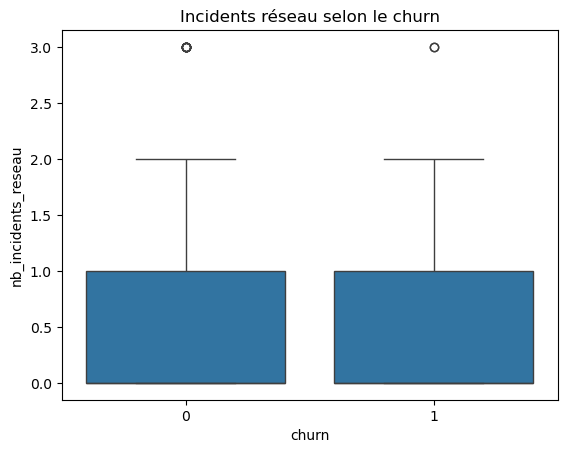

In [43]:
sns.boxplot(data=dataset_propre, x='churn', y='nb_incidents_reseau')
plt.title("Incidents réseau selon le churn")
plt.show()

In [ ]:
# b) Nombre de contacts au support

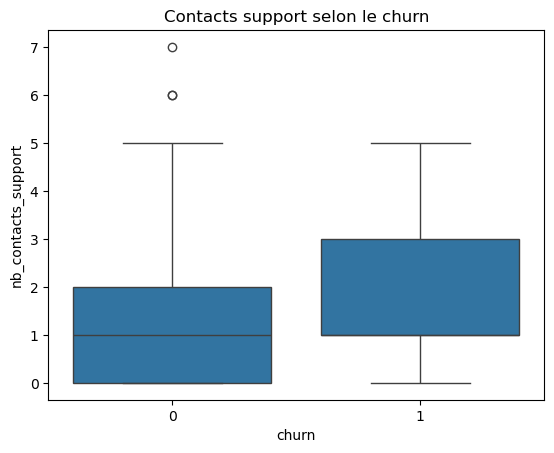

In [44]:
sns.boxplot(data=dataset_propre, x='churn', y='nb_contacts_support')
plt.title("Contacts support selon le churn")
plt.show()

In [ ]:
# c) Ancienneté (mois)

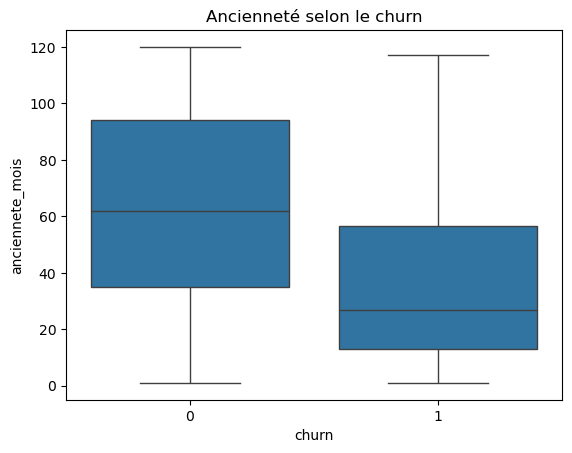

In [45]:
sns.boxplot(data=dataset_propre, x='churn', y='anciennete_mois')
plt.title("Ancienneté selon le churn")
plt.show()

In [ ]:
# d) Type d'offre (variable catégorielle)

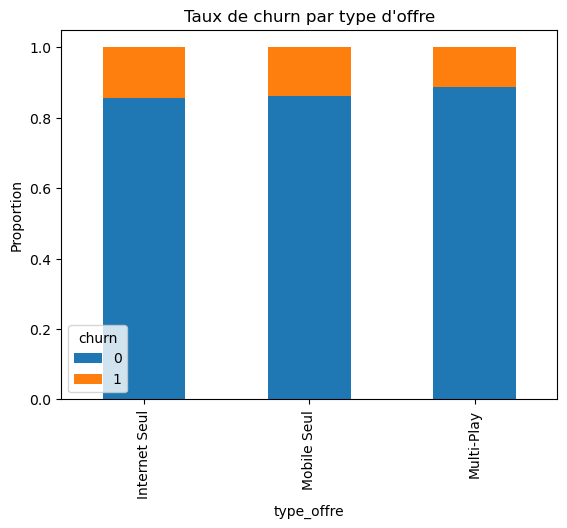

In [46]:
pd.crosstab(dataset_propre['type_offre'], dataset_propre['churn'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Taux de churn par type d'offre")
plt.ylabel("Proportion")
plt.show()

## **TACHE - 3 : MODELE DE PREDICTION**

### **1) Importation des bibliothèques**

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

### **2) Préparation du dataset**

In [52]:
# Copie du dataset
dataset_ml = dataset_propre.copy()

In [53]:
# Encodage des variables catégorielles
for col in ['region', 'type_offre', 'moyen_paiement']:
    le = LabelEncoder()
    dataset_ml[col] = le.fit_transform(dataset_ml[col])

In [54]:
# Séparer les features (X) et la cible (y)
X = dataset_ml.drop(columns=['client_id', 'churn'])
y = dataset_ml['churn']

### **3) Separation train/test**

In [ ]:
# On pose les variables suivantes:
#
# X_train : données dentrainement
# X_test : données de test
# y_train : reponse d'entraine,et
# y_test : reponse de test

In [55]:
# La separation du dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [56]:
# Il faut noter a ce niveau que "stratify=y" garde la même proportion de churn dans le train et le test — important vu le déséquilibre des classes.

### **4) Entrainement du modèle**

In [57]:
# Créqtion du modèle de prédctuion et entrainement du ,odele créé
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## **TACHE N-4 : RESTITUTION DES RESULTATS**

### **1) Importation des bibliothèques indispensables**

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

### **2) Evaluation du modèle**

In [60]:
#Evaluation du modèle fournit
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [62]:
# Precision/Recall/F1 (dans le rapport) : plus importants que l'accuracy ici, vu le déséquilibre des classes 
# le recall sur la classe churn (1) indique la capacité du modèle à bien détecter les clients qui vont partir
# Accuracy : proportion de prédictions correctes globales
print("Accuracy :", accuracy_score(y_test, y_pred))


Accuracy : 0.8444444444444444


In [63]:
# AUC-ROC : capacité du modèle à distinguer les deux classes (proche de 1 = excellent, 0.5 = aléatoire)

print("AUC-ROC :", roc_auc_score(y_test, y_proba))


AUC-ROC : 0.7381143162393162


In [64]:
print("\nRapport de classification :\n", classification_report(y_test, y_pred))



Rapport de classification :
               precision    recall  f1-score   support

           0       0.86      0.97      0.92       156
           1       0.00      0.00      0.00        24

    accuracy                           0.84       180
   macro avg       0.43      0.49      0.46       180
weighted avg       0.75      0.84      0.79       180



In [65]:
# Matrice de confusion : détail des vrais/faux positifs et négatifs
print("\nMatrice de confusion :\n", confusion_matrix(y_test, y_pred))


Matrice de confusion :
 [[152   4]
 [ 24   0]]


### **3) Identification des valeurs influentes : les features importantes**

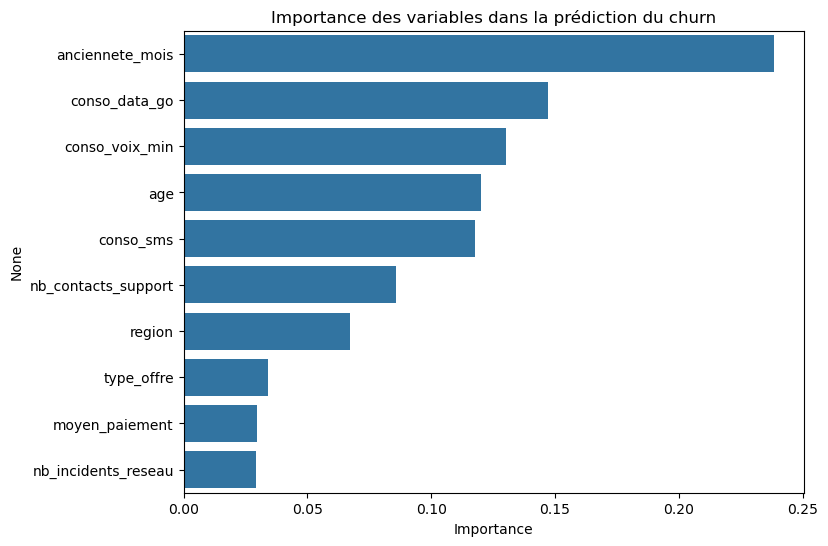

anciennete_mois        0.238403
conso_data_go          0.147257
conso_voix_min         0.130388
age                    0.120178
conso_sms              0.117854
nb_contacts_support    0.085858
region                 0.067071
type_offre             0.033922
moyen_paiement         0.029639
nb_incidents_reseau    0.029430
dtype: float64


In [66]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Importance des variables dans la prédiction du churn")
plt.xlabel("Importance")
plt.show()

print(importances)

In [67]:
# Le modèle Random Forest entraîné pour prédire le churn identifie 

# l'ancienneté (23,8%) comme la variable la plus déterminante, 
# la consommation data (14,7%) 
# la consommation voix (13%). 

# Ces résultats confirment l'intuition de l'analyse exploratoire : les clients récents sont plus à risque de résiliation. 

# Les contacts support (8,6%), bien que moins déterminants que prévu dans l'analyse visuelle, restent un facteur notable. 
# À l'inverse, le moyen de paiement et les incidents réseau ont un poids très faible (environ : 3%) et n'influencent presque pas les prédictions du modèle.
